In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

In [2]:
def score_dataset(X, y, model=RandomForestRegressor(random_state=1)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())

In [3]:
# Utility functions from Kaggle Tutorial(Feature engineering)
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [4]:
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [5]:
rain_file_path = 'data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)

In [6]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [7]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall

In [8]:
#cols = X.columns
cols = ["cloud", "sunshine"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine
0,88.0,1.1
1,91.0,0.0
2,47.0,8.3
3,95.0,0.0
4,45.0,3.6
...,...,...
2185,88.0,0.1
2186,88.0,0.0
2187,79.0,5.0
2188,93.0,0.1


In [9]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine
0,0.877551,0.090909
1,0.908163,0.000000
2,0.459184,0.685950
3,0.948980,0.000000
4,0.438776,0.297521
...,...,...
2185,0.877551,0.008264
2186,0.877551,0.000000
2187,0.785714,0.413223
2188,0.928571,0.008264


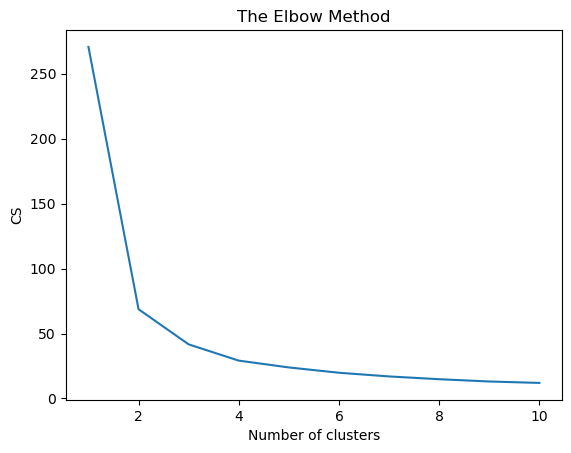

In [10]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 472 out of 2190 samples were correctly labeled.
Accuracy score: 0.22


In [12]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)

In [13]:
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [14]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [15]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)

In [16]:
X["cluster"] = X_scaled["cluster"]
X
X_test["cluster"] = X_test_scaled["cluster"]
X_test

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,cluster
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0.031709,1.201815,0
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0.124249,1.256857,0
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,1.218766,0.104357,1
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,0.146852,1.268664,0
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,1.098443,0.401087,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0.114143,1.248804,0
726,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0.114143,1.248804,0
727,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0.109646,1.248008,0
728,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0.114143,1.248804,0


In [17]:
#score_dataset(X, y)

In [18]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.202280
Centroid_0       0.194825
sunshine         0.166422
Centroid_1       0.156071
humidity         0.130347
cluster          0.091073
id               0.068340
day              0.057267
dewpoint         0.034847
mintemp          0.029092
temparature      0.025696
maxtemp          0.016384
winddirection    0.013790
pressure         0.012865
windspeed        0.007016
Name: MI Scores, dtype: float64

In [19]:
#X = X.drop(labels = ("day"), axis=1)
#X_test = X_test.drop(labels = ("day"), axis=1)


In [20]:
#score_dataset(X, y)

In [21]:
X = X.drop(labels = ("windspeed"), axis=1)
X_test = X_test.drop(labels = ("windspeed"), axis=1)
#score_dataset(X, y)

In [22]:
#X = X.drop(labels = ("id"), axis=1)
#X_test = X_test.drop(labels = ("id"), axis=1)
#score_dataset(X, y)

In [23]:
features = ["cloud", "sunshine", "Centroid_1", "humidity", "Centroid_0", "cluster", "winddirection"]
Z = X.loc[:, features]
W = X_test.loc[:, features]
# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(Z)
print(loadings)

                    PC1       PC2       PC3       PC4       PC5       PC6  \
cloud         -0.387466  0.135677  0.113339  0.870537  0.217870  0.110099   
sunshine       0.430002  0.059929  0.084681 -0.045117  0.878408  0.025159   
Centroid_1    -0.434070 -0.034014 -0.217638 -0.275260  0.135521  0.749406   
humidity      -0.287494  0.364741  0.834215 -0.295878  0.020539 -0.020728   
Centroid_0     0.440171  0.004119  0.205026  0.099169 -0.133428  0.630001   
cluster        0.432663  0.024467  0.241795  0.257539 -0.370928  0.167892   
winddirection  0.113801  0.918255 -0.369056 -0.025658 -0.082176  0.010784   

                    PC7  
cloud         -0.034545  
sunshine       0.173395  
Centroid_1     0.327592  
humidity       0.001459  
Centroid_0    -0.582801  
cluster        0.722245  
winddirection -0.011287  


In [24]:
X = X.join(X_pca)
X

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,...,Centroid_0,Centroid_1,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,...,0.031709,1.201815,0,-1.851954,-0.280988,0.233535,-0.028768,0.056916,-0.083313,0.086392
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,...,0.124249,1.256857,0,-2.329317,-0.020562,1.138964,-0.185224,-0.149552,0.103399,-0.033236
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,...,1.218766,0.104357,1,3.254315,-0.776856,0.292662,-0.239530,-0.132142,-0.226237,-0.059869
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,...,0.146852,1.268664,0,-2.393055,0.123645,1.121327,0.002084,-0.113810,0.175081,-0.059131
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,...,1.098443,0.401087,1,3.170212,-2.311763,-2.335251,0.407891,-1.208451,0.115017,0.059336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,...,0.106078,1.244331,0,-2.344551,-0.061988,1.381167,-0.400088,-0.145051,0.037367,-0.009514
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,...,0.114143,1.248804,0,-2.118435,-0.229669,0.692124,-0.175571,-0.196100,0.070758,-0.022649
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,...,0.309166,1.058299,0,-0.564877,-0.875334,-0.320621,-0.065690,0.780541,0.010881,-0.116074
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,...,0.127707,1.258185,0,-2.262439,-0.258977,0.879912,0.026986,-0.099278,0.129193,-0.034344


In [25]:
pca, X_pca, loadings = apply_pca(Z)
X_test = X_test.join(X_pca)

In [26]:
#když bylo vyhozené id a day bylo to 0.8745862843729195
#score_dataset(X, y)

In [27]:
X

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,...,Centroid_0,Centroid_1,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,...,0.031709,1.201815,0,-1.851954,-0.280988,0.233535,-0.028768,0.056916,-0.083313,0.086392
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,...,0.124249,1.256857,0,-2.329317,-0.020562,1.138964,-0.185224,-0.149552,0.103399,-0.033236
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,...,1.218766,0.104357,1,3.254315,-0.776856,0.292662,-0.239530,-0.132142,-0.226237,-0.059869
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,...,0.146852,1.268664,0,-2.393055,0.123645,1.121327,0.002084,-0.113810,0.175081,-0.059131
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,...,1.098443,0.401087,1,3.170212,-2.311763,-2.335251,0.407891,-1.208451,0.115017,0.059336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,...,0.106078,1.244331,0,-2.344551,-0.061988,1.381167,-0.400088,-0.145051,0.037367,-0.009514
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,...,0.114143,1.248804,0,-2.118435,-0.229669,0.692124,-0.175571,-0.196100,0.070758,-0.022649
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,...,0.309166,1.058299,0,-0.564877,-0.875334,-0.320621,-0.065690,0.780541,0.010881,-0.116074
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,...,0.127707,1.258185,0,-2.262439,-0.258977,0.879912,0.026986,-0.099278,0.129193,-0.034344


In [28]:
model=RandomForestRegressor(random_state=1)
model.fit(X, y)
rf_test_preds = model.predict(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=1,
    class_weight="balanced",
    solver="liblinear",
)
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.8928731762065094


In [30]:
#model.fit(X, y)
#rf_test_preds = model.predict(X_test)

In [31]:
#X_test["id"] = test_data["id"]
#X_test["rainfall"] = rf_test_preds
#X_test.to_csv('submission_k-mean_PCA_2.csv', columns=['id','rainfall'], index=False)

In [32]:
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.8928731762065094


In [33]:
%%time
from sklearn.ensemble import RandomForestClassifier

# Parametr tuning GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}

parameters = {
    "n_estimators": [5, 10, 15, 20, 25], 
    "max_depth": [3, 5, 7, 9, 11, 13],
}

model_random_forest = RandomForestClassifier(
    random_state=0,
    class_weight='balanced',
)

model_random_forest = GridSearchCV(
    model_random_forest, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_random_forest.fit(X, y)

print('-----')
print(f'Best parameters {model_random_forest.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + \
    f'{model_random_forest.best_score_:.3f}'
)
cross_valid_scores['desicion_tree'] = model_random_forest.best_score_
print('-----')

-----
Best parameters {'max_depth': 3, 'n_estimators': 25}
Mean cross-validated accuracy score of the best_estimator: 0.880
-----
CPU times: user 9.04 s, sys: 11.7 ms, total: 9.05 s
Wall time: 9.05 s


In [34]:
%%time
from sklearn.ensemble import RandomForestClassifier

# Parametr tuning GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}

parameters = {
    "n_estimators": [46], 
    "max_depth": [10, 11, 12],
}

model_random_forest = RandomForestClassifier(
    random_state=0,
    class_weight='balanced',
)

model_random_forest = GridSearchCV(
    model_random_forest, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_random_forest.fit(X, y)

print('-----')
print(f'Best parameters {model_random_forest.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + \
    f'{model_random_forest.best_score_:.3f}'
)
cross_valid_scores['desicion_tree'] = model_random_forest.best_score_
print('-----')

-----
Best parameters {'max_depth': 10, 'n_estimators': 46}
Mean cross-validated accuracy score of the best_estimator: 0.870
-----
CPU times: user 3.32 s, sys: 3 μs, total: 3.32 s
Wall time: 3.32 s


In [35]:
%%time
parameters = {
    "max_depth": [3, 5, 7, 9, 11, 13],
}

model_desicion_tree = DecisionTreeClassifier(
    random_state=0,
    class_weight='balanced',
)

model_desicion_tree = GridSearchCV(
    model_desicion_tree, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_desicion_tree.fit(X, y)

print('-----')
print(f'Best parameters {model_desicion_tree.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + \
    f'{model_desicion_tree.best_score_:.3f}'
)
cross_valid_scores['desicion_tree'] = model_desicion_tree.best_score_
print('-----')

-----
Best parameters {'max_depth': 3}
Mean cross-validated accuracy score of the best_estimator: 0.668
-----
CPU times: user 776 ms, sys: 0 ns, total: 776 ms
Wall time: 775 ms


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

In [38]:
%%time
parameters = {
    "n_estimators": [5, 10, 15, 20, 25, 50, 75, 100], 
    "learning_rate": [0.001, 0.01, 0.1, 1.],
}

model_adaboost = AdaBoostClassifier(
    random_state=0,
)

model_adaboost = GridSearchCV(
    model_adaboost, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_adaboost.fit(X, y)

print('-----')
print(f'Best parameters {model_adaboost.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: '+ \
    f'{model_adaboost.best_score_:.3f}'
)
cross_valid_scores['ada_boost'] = model_adaboost.best_score_
print('-----')

-----
Best parameters {'learning_rate': 0.1, 'n_estimators': 100}
Mean cross-validated accuracy score of the best_estimator: 0.885
-----
CPU times: user 28.5 s, sys: 23.9 ms, total: 28.5 s
Wall time: 28.5 s


In [39]:
%%time
import xgboost as xgb
import lightgbm as lgbm
import catboost as cb


parameters = {
    'max_depth': [3, 5, 7, 9], 
    'n_estimators': [5, 10, 15, 20, 25, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1]
}

model_xgb = xgb.XGBClassifier(
    random_state=0,
)

model_xgb = GridSearchCV(
    model_xgb, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_xgb.fit(X, y)

print('-----')
print(f'Best parameters {model_xgb.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_xgb.best_score_:.3f}'
)
cross_valid_scores['xgboost'] = model_xgb.best_score_
print('-----')

-----
Best parameters {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Mean cross-validated accuracy score of the best_estimator: 0.884
-----
CPU times: user 3min 16s, sys: 7.28 s, total: 3min 24s
Wall time: 26.3 s


In [40]:
%%time
parameters = {
    'n_estimators': [5, 10, 15, 20, 25, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [7, 15, 31],
}

model_lgbm = lgbm.LGBMClassifier(
    random_state=0,
    class_weight='balanced',
)

model_lgbm = GridSearchCV(
    model_lgbm, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_lgbm.fit(
    X, 
    y, 
 #   categorical_feature=categorical_columns
)

print('-----')
print(f'Best parameters {model_lgbm.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_lgbm.best_score_:.3f}'
)
cross_valid_scores['lightgbm'] = model_lgbm.best_score_
print('-----')

[LightGBM] [Info] Number of positive: 1320, number of negative: 432
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3897
[LightGBM] [Info] Number of data points in the train set: 1752, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 1320, number of negative: 432
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000429 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3908
[LightGBM] [Info] Number of data points in the train set: 1752, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number

In [41]:
%%time
parameters = {
    'iterations': [5, 10, 15, 20, 25, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7, 9, 11, 13],
}

model_catboost = cb.CatBoostClassifier(
    verbose=False,
)

model_catboost = GridSearchCV(
    model_catboost, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_catboost.fit(X, y)

print('-----')
print(f'Best parameters {model_catboost.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_catboost.best_score_:.3f}'
)
cross_valid_scores['catboost'] = model_catboost.best_score_
print('-----')

-----
Best parameters {'depth': 7, 'iterations': 20, 'learning_rate': 0.01}
Mean cross-validated accuracy score of the best_estimator: 0.892
-----
CPU times: user 45min 54s, sys: 1min 28s, total: 47min 23s
Wall time: 6min 58s


In [42]:
%%time
parameters = {
    "C": [0.001, 0.01, 0.1, 1.],
    "penalty": ["l1", "l2"]
}

model_logistic_regression = LogisticRegression(
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

model_logistic_regression = GridSearchCV(
    model_logistic_regression, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_logistic_regression.fit(X, y)

print('-----')
print(f'Best parameters {model_logistic_regression.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_logistic_regression.best_score_:.3f}'
)
cross_valid_scores['logistic_regression'] = model_logistic_regression.best_score_
print('-----')

/opt/conda/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


-----
Best parameters {'C': 0.01, 'penalty': 'l2'}
Mean cross-validated accuracy score of the best_estimator: 0.893
-----
CPU times: user 7.15 s, sys: 8.08 ms, total: 7.15 s
Wall time: 7.15 s


/opt/conda/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
%%time
parameters = {
    "C": [0.001, 0.01, 0.1, 1.],
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "gamma": ["scale", "auto"],
}

model_svc = SVC(
    random_state=0,
    class_weight="balanced",
    probability=True,
)

model_svc = GridSearchCV(
    model_svc, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_svc.fit(X, y)

print('-----')
print(f'Best parameters {model_svc.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_svc.best_score_:.3f}'
)
cross_valid_scores['svc'] = model_svc.best_score_
print('-----')


In [ ]:
%%time
parameters = {
    "weights": ["uniform", "distance"],
}

model_k_neighbors = KNeighborsClassifier(
)

model_k_neighbors = GridSearchCV(
    model_k_neighbors, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_k_neighbors.fit(X, y)

print('-----')
print(f'Best parameters {model_k_neighbors.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_k_neighbors.best_score_:.3f}'
)
cross_valid_scores['k_neighbors'] = model_k_neighbors.best_score_
print('-----')